In [ ]:
import os

print("Files in current directory:")
for f in os.listdir():
    print(f)


Files in current directory:
.config
scaler.pkl
features_dataset.csv
label_encoder.pkl
instrument_classifier_random_forest.pkl
sample_data


In [ ]:
import pandas as pd
import joblib

# Load dataset
df = pd.read_csv("features_dataset.csv")

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# Split features and labels
X = df.drop("label", axis=1)
y = df["label"]

# Load saved label encoder
le = joblib.load("label_encoder.pkl")

# Encode labels
y = le.transform(y)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)


Dataset shape: (42311, 37)
Columns: ['mfcc_0', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'mfcc_14', 'mfcc_15', 'mfcc_16', 'mfcc_17', 'mfcc_18', 'mfcc_19', 'chroma_0', 'chroma_1', 'chroma_2', 'chroma_3', 'chroma_4', 'chroma_5', 'chroma_6', 'chroma_7', 'chroma_8', 'chroma_9', 'chroma_10', 'chroma_11', 'centroid', 'bandwidth', 'rolloff', 'zcr', 'label']
Feature matrix shape: (42311, 36)
Labels shape: (42311,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed.")


Train shape: (33848, 36)
Test shape: (8463, 36)
Scaling completed.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train Logistic Regression
lr = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial",
    n_jobs=-1
)

lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.8968450903934775
                 precision    recall  f1-score   support

      Accordion       0.78      0.82      0.80       716
Acoustic_Guitar       0.89      0.89      0.89       731
          Banjo       0.83      0.85      0.84       600
    Bass_Guitar       1.00      1.00      1.00       723
       Clarinet       0.84      0.87      0.85       127
        Cymbals       0.59      0.32      0.41        41
          Dobro       0.88      0.90      0.89        97
       Drum_set       1.00      1.00      1.00       730
 Electro_Guitar       0.86      0.79      0.83       263
      Floor_Tom       0.78      0.85      0.82        81
      Harmonica       0.95      0.73      0.83        26
      Harmonium       1.00      1.00      1.00       263
        Hi_Hats       0.73      0.75      0.74        89
           Horn       0.99      1.00      1.00       252
       Keyboard       0.99      1.00      0.99       408
       Mandolin       0.70      0.74  

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

n_estimators_list = list(range(100, 1100, 100))
rf_accuracies = []

for n in n_estimators_list:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    rf_temp.fit(X_train, y_train)
    y_pred = rf_temp.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    rf_accuracies.append(acc)

    print(f"n_estimators = {n}, Accuracy = {acc:.4f}")


n_estimators = 100, Accuracy = 0.9709
n_estimators = 200, Accuracy = 0.9712
n_estimators = 300, Accuracy = 0.9716
n_estimators = 400, Accuracy = 0.9719
n_estimators = 500, Accuracy = 0.9718
n_estimators = 600, Accuracy = 0.9718
n_estimators = 700, Accuracy = 0.9722
n_estimators = 800, Accuracy = 0.9721
n_estimators = 900, Accuracy = 0.9725
n_estimators = 1000, Accuracy = 0.9724


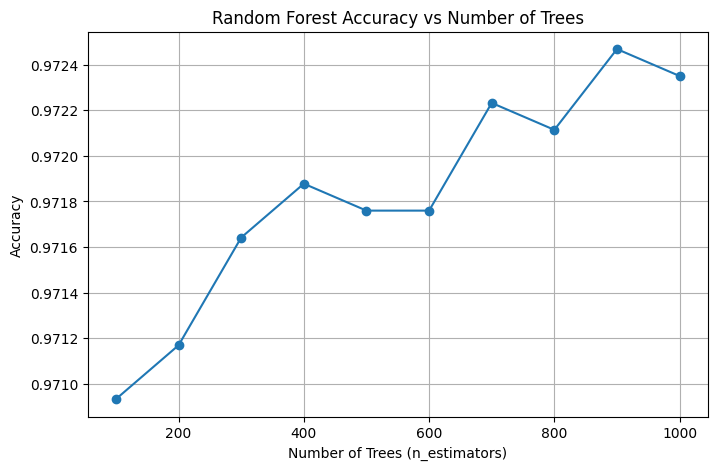

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(n_estimators_list, rf_accuracies, marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.grid(True)
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import joblib

rf_final = RandomForestClassifier(
    n_estimators=700,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

joblib.dump(rf_final, "final_random_forest_model.pkl")


['final_random_forest_model.pkl']

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

degrees = list(range(3, 11))
svm_poly_accuracies = []

for d in degrees:
    svm_poly = SVC(
        kernel="poly",
        degree=d,
        C=1.0
    )

    svm_poly.fit(X_train, y_train)
    y_pred = svm_poly.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    svm_poly_accuracies.append(acc)

    print(f"Polynomial Degree = {d}, Accuracy = {acc:.4f}")


Polynomial Degree = 3, Accuracy = 0.9384
Polynomial Degree = 4, Accuracy = 0.8607
Polynomial Degree = 5, Accuracy = 0.7825
Polynomial Degree = 6, Accuracy = 0.7216
Polynomial Degree = 7, Accuracy = 0.6741
Polynomial Degree = 8, Accuracy = 0.6394
Polynomial Degree = 9, Accuracy = 0.6121
Polynomial Degree = 10, Accuracy = 0.5927


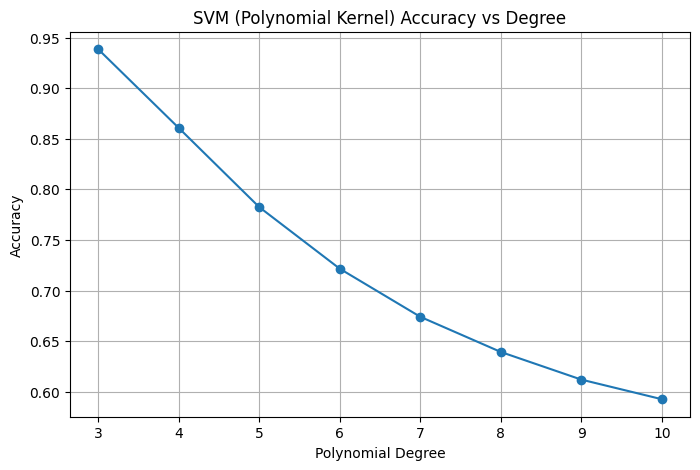

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(degrees, svm_poly_accuracies, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("Accuracy")
plt.title("SVM (Polynomial Kernel) Accuracy vs Degree")
plt.grid(True)
plt.show()


In [ ]:
svm_poly_final = SVC(
    kernel="poly",
    degree=3,
    C=1.0
)

svm_poly_final.fit(X_train, y_train)


SVC(kernel='poly')

In [ ]:
import joblib
joblib.dump(svm_poly_final, "svm_poly_final.pkl")


['svm_poly_final.pkl']

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

gamma_values = np.arange(0.1, 1.1, 0.1)
svm_rbf_accuracies = []

for g in gamma_values:
    svm_rbf = SVC(
        kernel="rbf",
        gamma=g
    )

    svm_rbf.fit(X_train, y_train)
    y_pred = svm_rbf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    svm_rbf_accuracies.append(acc)

    print(f"gamma = {g:.1f}, Accuracy = {acc:.4f}")


gamma = 0.1, Accuracy = 0.9820
gamma = 0.2, Accuracy = 0.9627
gamma = 0.3, Accuracy = 0.9261
gamma = 0.4, Accuracy = 0.8914
gamma = 0.5, Accuracy = 0.8561
gamma = 0.6, Accuracy = 0.8245
gamma = 0.7, Accuracy = 0.8022
gamma = 0.8, Accuracy = 0.7848
gamma = 0.9, Accuracy = 0.7724
gamma = 1.0, Accuracy = 0.7601


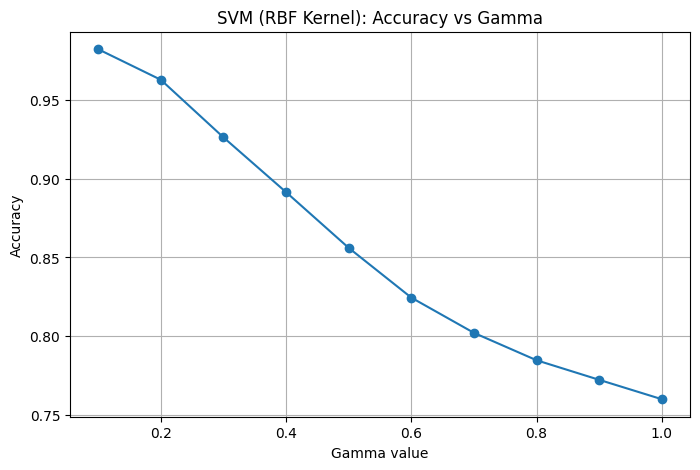

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(gamma_values, svm_rbf_accuracies, marker='o')
plt.xlabel("Gamma value")
plt.ylabel("Accuracy")
plt.title("SVM (RBF Kernel): Accuracy vs Gamma")
plt.grid(True)
plt.show()


In [ ]:
svm_rbf_final = SVC(
    kernel="rbf",
    gamma=0.2
)

svm_rbf_final.fit(X_train, y_train)


SVC(gamma=0.2)

In [ ]:
import joblib

joblib.dump(svm_rbf_final, "final_svm_rbf_model.pkl")


['final_svm_rbf_model.pkl']

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = [1] + list(range(5, 101, 5))
knn_accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)

    y_pred = knn_temp.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    knn_accuracies.append(acc)

    print(f"k = {k}, Accuracy = {acc:.4f}")


k = 1, Accuracy = 0.9791
k = 5, Accuracy = 0.9616
k = 10, Accuracy = 0.9490
k = 15, Accuracy = 0.9419
k = 20, Accuracy = 0.9338
k = 25, Accuracy = 0.9271
k = 30, Accuracy = 0.9201
k = 35, Accuracy = 0.9165
k = 40, Accuracy = 0.9111
k = 45, Accuracy = 0.9061
k = 50, Accuracy = 0.9017
k = 55, Accuracy = 0.8990
k = 60, Accuracy = 0.8953
k = 65, Accuracy = 0.8903
k = 70, Accuracy = 0.8868
k = 75, Accuracy = 0.8824
k = 80, Accuracy = 0.8789
k = 85, Accuracy = 0.8743
k = 90, Accuracy = 0.8713
k = 95, Accuracy = 0.8679
k = 100, Accuracy = 0.8644


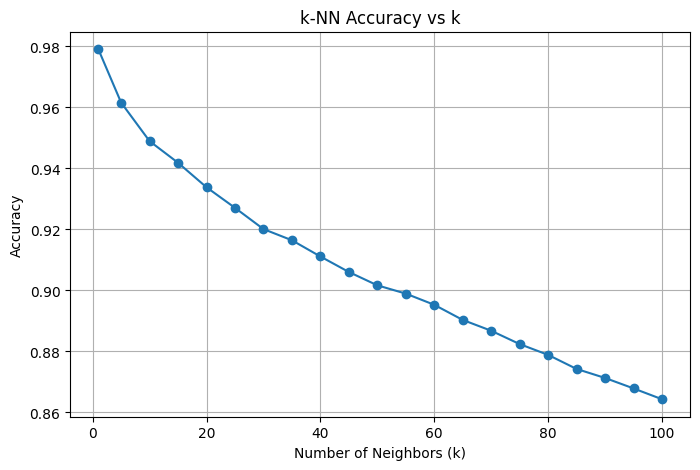

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(k_values, knn_accuracies, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("k-NN Accuracy vs k")
plt.grid(True)
plt.show()


In [ ]:
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train, y_train)


KNeighborsClassifier()

In [ ]:
from sklearn.metrics import classification_report

y_pred_knn = knn_final.predict(X_test)

print("k-NN Accuracy (k=5):", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))


k-NN Accuracy (k=5): 0.9615975422427036
                 precision    recall  f1-score   support

      Accordion       0.92      0.99      0.95       716
Acoustic_Guitar       0.98      1.00      0.99       731
          Banjo       0.92      0.99      0.96       600
    Bass_Guitar       0.99      1.00      1.00       723
       Clarinet       0.95      0.89      0.92       127
        Cymbals       1.00      0.76      0.86        41
          Dobro       0.93      0.95      0.94        97
       Drum_set       1.00      1.00      1.00       730
 Electro_Guitar       0.99      0.88      0.93       263
      Floor_Tom       0.81      0.96      0.88        81
      Harmonica       1.00      0.96      0.98        26
      Harmonium       1.00      1.00      1.00       263
        Hi_Hats       0.84      0.84      0.84        89
           Horn       1.00      1.00      1.00       252
       Keyboard       1.00      1.00      1.00       408
       Mandolin       0.95      0.96      0.95 

In [ ]:
import joblib
joblib.dump(knn_final, "knn_k5_model.pkl")


['knn_k5_model.pkl']

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))


Naive Bayes Accuracy: 0.7806924258537161
                 precision    recall  f1-score   support

      Accordion       0.67      0.62      0.64       716
Acoustic_Guitar       0.83      0.74      0.78       731
          Banjo       0.68      0.59      0.63       600
    Bass_Guitar       1.00      0.99      0.99       723
       Clarinet       0.65      0.57      0.61       127
        Cymbals       0.29      0.46      0.36        41
          Dobro       0.39      0.73      0.51        97
       Drum_set       1.00      0.99      1.00       730
 Electro_Guitar       0.67      0.55      0.60       263
      Floor_Tom       0.37      0.77      0.50        81
      Harmonica       0.71      0.92      0.80        26
      Harmonium       1.00      0.98      0.99       263
        Hi_Hats       0.49      0.79      0.60        89
           Horn       1.00      0.91      0.95       252
       Keyboard       1.00      0.93      0.96       408
       Mandolin       0.58      0.46      0.51

In [ ]:
from sklearn.metrics import accuracy_score
import pandas as pd

model_names = []
accuracies = []

# Logistic Regression
model_names.append("Logistic Regression")
accuracies.append(accuracy_score(y_test, lr.predict(X_test)))

# Random Forest
model_names.append("Random Forest")
accuracies.append(accuracy_score(y_test, rf_final.predict(X_test)))

# SVM Polynomial
model_names.append("SVM (Polynomial)")
accuracies.append(accuracy_score(y_test, svm_poly.predict(X_test)))

# SVM RBF
model_names.append("SVM (RBF)")
accuracies.append(accuracy_score(y_test, svm_rbf.predict(X_test)))

# k-NN
model_names.append("k-NN")
accuracies.append(accuracy_score(y_test, knn_temp.predict(X_test)))

# Naive Bayes
model_names.append("Naive Bayes")
accuracies.append(accuracy_score(y_test, nb.predict(X_test)))

# Create comparison table
results_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracies
})

results_df


,Model,Accuracy
0,Logistic Regression,0.896845
1,Random Forest,0.972232
2,SVM (Polynomial),0.592698
3,SVM (RBF),0.760132
4,k-NN,0.864351
5,Naive Bayes,0.780692


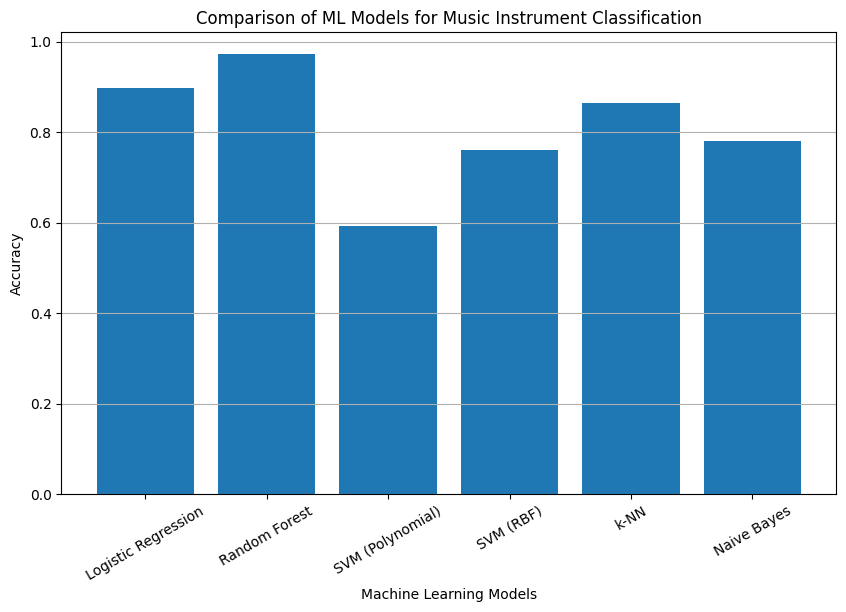

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(model_names, accuracies)
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Comparison of ML Models for Music Instrument Classification")
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.show()


In [ ]:
import joblib

rf_final = joblib.load("final_random_forest_model.pkl")
le = joblib.load("label_encoder.pkl")
scaler = joblib.load("scaler.pkl")


In [ ]:
import librosa
import numpy as np

def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=22050, duration=5.0, mono=True)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
    mfcc_mean = np.mean(mfcc.T, axis=0)

    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    chroma_mean = np.mean(chroma.T, axis=0)

    centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=audio))

    features = np.hstack([
        mfcc_mean,
        chroma_mean,
        centroid,
        bandwidth,
        rolloff,
        zcr
    ])

    return features


In [ ]:
import pandas as pd

file_path = "/content/104 (1).wav"  # change to your audio file

features = extract_features(file_path).reshape(1, -1)

# convert to DataFrame to avoid warning
features_df = pd.DataFrame(features, columns=X.columns)

# scale
features_scaled = scaler.transform(features_df)

# predict
prediction = rf_final.predict(features_scaled)
predicted_label = le.inverse_transform(prediction)[0]

print("Predicted Instrument:", predicted_label)


Predicted Instrument: Harmonica
